In [1]:
# Import
from pathlib import Path

import torch
from PIL import Image
from transformers import CLIPTokenizer

from stable_diffusion.utils import preload_models_from_standard_weights
from stable_diffusion import generate

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# CONSTANTS
DEVICE = "cuda"

ALLOW_CUDA = True
ALLOW_MPS = False
PREFERRED_DEVICE = 2

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = f"cuda:{PREFERRED_DEVICE}"
elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

Using device: cuda:2


In [3]:
tokenizer = CLIPTokenizer("/app/Stable-Diffusion/_tokenizer_data/vocab.json",
                          merges_file="/app/Stable-Diffusion/_tokenizer_data/merges.txt")
model_file = "/app/Stable-Diffusion/_model_weights/v1-5-pruned-emaonly.ckpt"

models = preload_models_from_standard_weights(model_file, DEVICE)



In [4]:
## TEXT TO IMAGE
prompt = "A cat with chef clothes and cooking, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
uncond_prompt = ""  # Optional: negative prompt
do_cfg = True
cfg_scale = 8  # min: 1, max: 14
input_image = None  # No image for Text-to-Image
strength = 1  # Use 1 as a default value for Text-to-Image

In [5]:
# ## IMAGE TO IMAGE
# image_path = "/app/Stable-Diffusion/_test_data/input/cat.jpg"  # Path to input image
# prompt = "A cat wearing chef clothes and wearing sunglasses, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
# uncond_prompt = ""  # Optional: negative prompt
# do_cfg = True
# cfg_scale = 8  # min: 1, max: 14
# input_image = Image.open(image_path)
# strength = 0.8  # Strength to control how much transformation occurs

In [6]:
## SAMPLER
sampler = "ddpm"
num_inference_steps = 50
seed = 42

In [7]:
output_image = generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cuda",
    tokenizer=tokenizer,
)

100%|██████████| 50/50 [00:02<00:00, 20.18it/s]


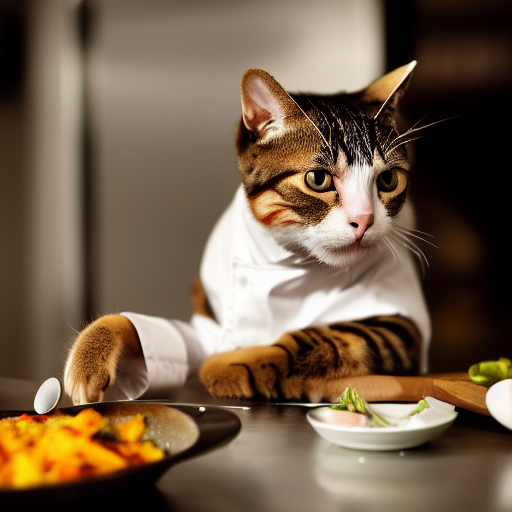

In [8]:
output_pil = Image.fromarray(output_image)
# Show the image
output_pil.show()

# Save the image (optional)
output_pil.save("/app/Stable-Diffusion/_test_data/output/output.png")